# Subset EDA — Gym99 with Apparatus Filtering
Mirrors the exact data pipeline from `scripts/train_gym99.py`.
Set `APPARATUS` in the config cell to match your training run.

In [1]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/schizocatto/Yolo-ST-GCN.git'
BRANCH   = 'experiment-bonestream'
REPO_DIR = Path('/content/Yolo-ST-GCN') if IN_COLAB else Path(os.getcwd())

if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'huggingface_hub', 'scipy', 'scikit-learn'], check=True)
    if not REPO_DIR.exists():
        subprocess.run(['git', 'clone', '-b', BRANCH, '--single-branch',
                        REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', 'origin', BRANCH], check=True)

os.chdir(str(REPO_DIR))
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print('Working dir:', os.getcwd())

Working dir: /content/Yolo-ST-GCN


In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
SEED = 42
np.random.seed(SEED)

In [3]:
if IN_COLAB:
    GYM288_PKL = '/content/Gym288-skeleton/gym_288_skeleton.pkl'
    GYM99_PKL  = '/content/Gym99-from-Gym288/gym99_from_gym288.pkl'
else:
    GYM288_PKL = 'data/Gym288-skeleton/gym_288_skeleton.pkl'
    GYM99_PKL  = 'data/Gym99-from-Gym288/gym99_from_gym288.pkl'

In [4]:
if IN_COLAB and not Path(GYM288_PKL).exists():
    from huggingface_hub import snapshot_download
    dl = Path(GYM288_PKL).parent
    dl.mkdir(parents=True, exist_ok=True)
    snapshot_download(repo_id='Lozumi/Gym288-skeleton', repo_type='dataset',
                      local_dir=str(dl), local_dir_use_symlinks=False)
    GYM288_PKL = str(sorted(dl.rglob('*.pkl'))[0])
print('Gym288:', GYM288_PKL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Gym288: /content/Gym288-skeleton/gym_288_skeleton.pkl


In [5]:
if not Path(GYM99_PKL).exists():
    from src.gym99_builder import build_gym99_from_gym288_pickle
    Path(GYM99_PKL).parent.mkdir(parents=True, exist_ok=True)
    stats = build_gym99_from_gym288_pickle(GYM288_PKL, GYM99_PKL)
    print('Build stats:', stats)

with open(GYM99_PKL, 'rb') as f:
    raw99 = pickle.load(f)

anns99 = raw99['annotations']
split99 = raw99['split']
train_ids99 = set(split99.get('train', []))
test_ids99  = set(split99.get('test',  []))
print(f'Gym99  total={len(anns99)}  train={len(train_ids99)}  test={len(test_ids99)}')

Build stats: {'map_size': 99, 'annotations_in': 38223, 'annotations_out': 36665, 'matched_direct': 34240, 'matched_minus1': 1625, 'matched_plus1': 800, 'train_count': 27624, 'test_count': 9041}
Gym99  total=36665  train=27624  test=9041


In [6]:
from src.gym99_dataset import build_gym99_data_tensors

data, labels, flags, raw_frame_counts_list, video_ids = build_gym99_data_tensors(
    dataset_path=GYM99_PKL,
    joint_spec_name='coco18',
    split='all',
    keep_unknown_split=False,
)
raw_frame_counts = np.array(raw_frame_counts_list)
print(f'Tensor shape: {data.shape}  dtype={data.dtype}')
print(f'Total: {len(data)}  train={(flags==1).sum()}  test={(flags==0).sum()}')

Tensor shape: (36665, 2, 48, 18, 1)  dtype=float32
Total: 36665  train=27624  test=9041


---
## Config — edit here to match your training run

In [7]:
# ── Edit to match your train_gym99.py arguments ───────────────
APPARATUS  = 'FX'    # 'all' | 'VT' | 'FX' | 'BB' | 'UB'
# ─────────────────────────────────────────────────────────────

In [8]:
# Exact split logic from scripts/train_gym99.py
APPARATUS_RANGES = {'VT': (0, 5), 'FX': (6, 40), 'BB': (41, 73), 'UB': (74, 98)}

train_mask = flags == 1
test_mask  = flags == 0

X_train, y_train = data[train_mask], labels[train_mask]
X_val,   y_val   = data[test_mask],  labels[test_mask]
fc_train = raw_frame_counts[train_mask]
fc_val   = raw_frame_counts[test_mask]
ids_train = [video_ids[i] for i, m in enumerate(train_mask) if m]
ids_val   = [video_ids[i] for i, m in enumerate(test_mask)  if m]

apparatus_label_offset = 0
if APPARATUS != 'all':
    lo, hi = APPARATUS_RANGES[APPARATUS]
    apparatus_label_offset = lo

    def _filter(X, y, fc, ids):
        mask = (y >= lo) & (y <= hi)
        return X[mask], y[mask] - lo, fc[mask], [ids[i] for i, m in enumerate(mask) if m]

    X_train, y_train, fc_train, ids_train = _filter(X_train, y_train, fc_train, ids_train)
    X_val,   y_val,   fc_val,   ids_val   = _filter(X_val,   y_val,   fc_val,   ids_val)
    print(f'[apparatus={APPARATUS}] global labels [{lo}, {hi}] → local [0, {hi - lo}]')

num_classes = int(y_train.max()) + 1
print(f'train={len(X_train)}  val={len(X_val)}  num_classes={num_classes}')

[apparatus=FX] global labels [6, 40] → local [0, 34]
train=5824  val=2411  num_classes=35


---
## 1. Subset Overview

In [9]:
def gini(values):
    v = np.sort(np.array(values, dtype=float))
    n = len(v)
    idx = np.arange(1, n + 1)
    return float((2 * np.dot(idx, v)) / (n * v.sum()) - (n + 1) / n)

def effective_n(values):
    v = np.array(values, dtype=float)
    p = v / v.sum()
    return float(np.exp(-np.sum(p * np.log(p + 1e-12))))

counts_tr = Counter(y_train.tolist())
counts_va = Counter(y_val.tolist())
counts_all = Counter((np.concatenate([y_train, y_val])).tolist())
vals_all = np.array(sorted(counts_all.values(), reverse=True))

global_range = (
    f'[{apparatus_label_offset}, {apparatus_label_offset + num_classes - 1}]'
    if APPARATUS != 'all' else '[0, 98]'
)

rows = [{
    'Apparatus':       APPARATUS,
    'Global label range': global_range,
    'Local classes':   num_classes,
    'Train samples':   len(X_train),
    'Val samples':     len(X_val),
    'Total':           len(X_train) + len(X_val),
    'Min/class':       int(vals_all.min()),
    'Median/class':    int(np.median(vals_all)),
    'Max/class':       int(vals_all.max()),
    'Imbalance ratio': f'{vals_all.max() / max(vals_all.min(), 1):.0f}x',
    'Gini':            f'{gini(vals_all):.3f}',
    'Effective N':     f'{effective_n(vals_all):.1f} / {num_classes}',
}]
display(pd.DataFrame(rows).set_index('Apparatus').T)

Apparatus,FX
Global label range,"[6, 40]"
Local classes,35
Train samples,5824
Val samples,2411
Total,8235
Min/class,80
Median/class,193
Max/class,633
Imbalance ratio,8x
Gini,0.306


---
## 2. Class Distribution

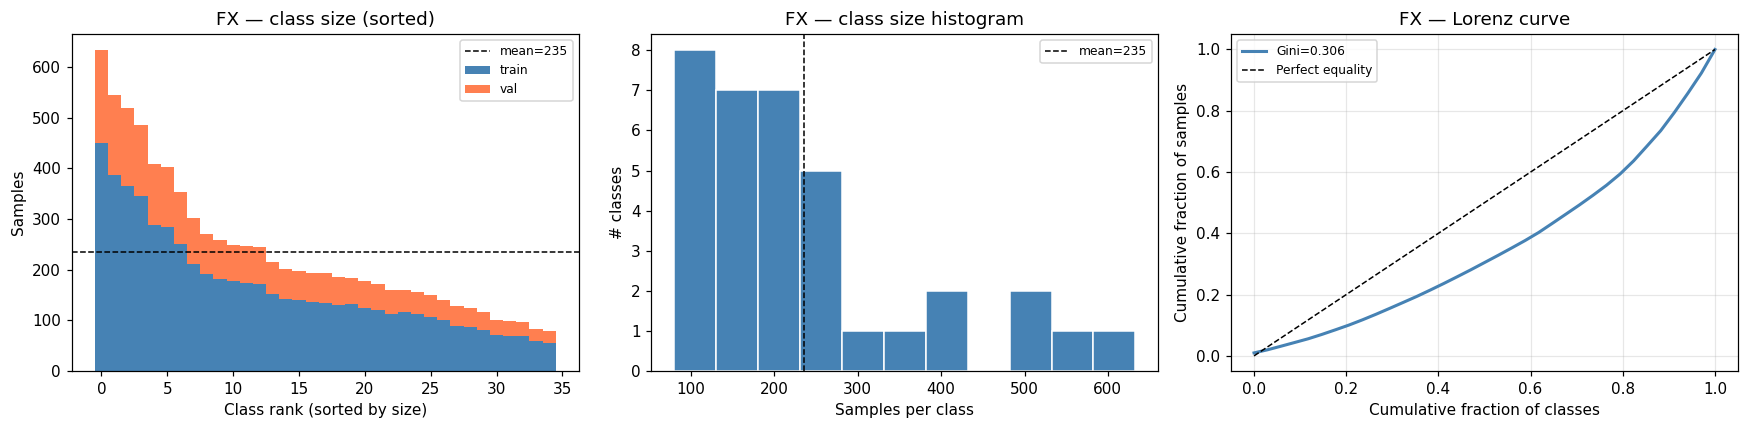

Gini=0.306  EffN=30.1/35  <5: 0  <10: 0


In [10]:
classes = np.arange(num_classes)
tr_counts = np.array([counts_tr.get(c, 0) for c in classes])
va_counts = np.array([counts_va.get(c, 0) for c in classes])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Stacked train/val bar
ax = axes[0]
sort_idx = np.argsort(tr_counts + va_counts)[::-1]
x = np.arange(num_classes)
ax.bar(x, tr_counts[sort_idx], label='train', color='steelblue', width=1.0)
ax.bar(x, va_counts[sort_idx], bottom=tr_counts[sort_idx], label='val', color='coral', width=1.0)
ax.axhline((tr_counts + va_counts).mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean={int((tr_counts+va_counts).mean())}')
ax.set_xlabel('Class rank (sorted by size)')
ax.set_ylabel('Samples')
ax.set_title(f'{APPARATUS} — class size (sorted)')
ax.legend(fontsize=8)

# Histogram
ax = axes[1]
total_per_class = tr_counts + va_counts
ax.hist(total_per_class, bins=max(10, num_classes // 3), color='steelblue', edgecolor='white')
ax.axvline(total_per_class.mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean={total_per_class.mean():.0f}')
ax.set_xlabel('Samples per class')
ax.set_ylabel('# classes')
ax.set_title(f'{APPARATUS} — class size histogram')
ax.legend(fontsize=8)

# Lorenz curve
ax = axes[2]
v = np.sort(total_per_class)
cumulative = np.cumsum(v) / v.sum()
x_lorenz = np.linspace(0, 1, len(v))
ax.plot(x_lorenz, cumulative, color='steelblue', linewidth=2,
        label=f'Gini={gini(v):.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect equality')
ax.set_xlabel('Cumulative fraction of classes')
ax.set_ylabel('Cumulative fraction of samples')
ax.set_title(f'{APPARATUS} — Lorenz curve')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Gini={gini(vals_all):.3f}  EffN={effective_n(vals_all):.1f}/{num_classes}  '
      f'<5: {(vals_all<5).sum()}  <10: {(vals_all<10).sum()}')

---
## 3. Train / Val Split Quality

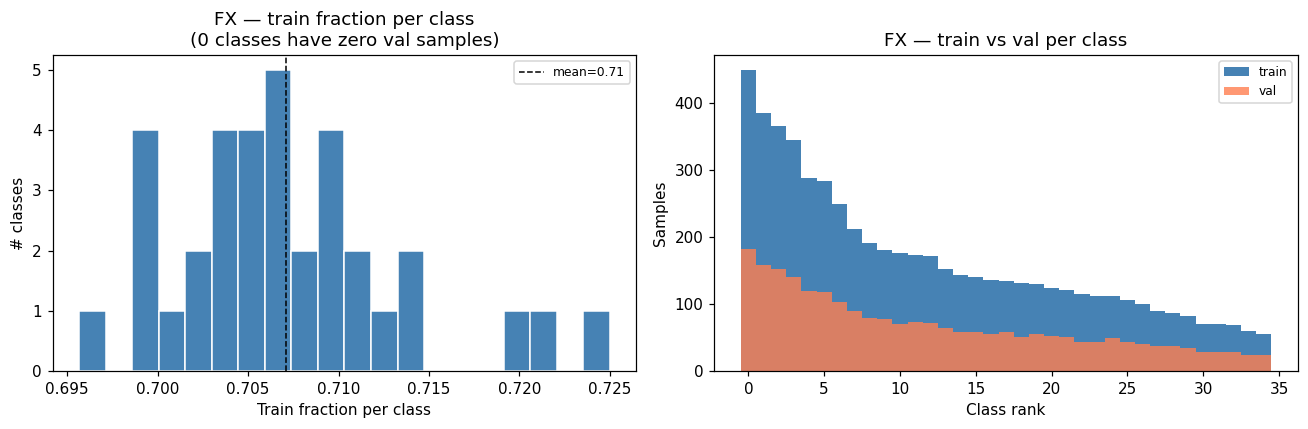

zero-val classes: 0/35  mean_train_frac=0.707  std=0.006
frame_dir overlap train∩val: 0  ✓ clean


In [11]:
ratios = []
zero_val = 0
for c in classes:
    tr = counts_tr.get(c, 0)
    va = counts_va.get(c, 0)
    total = tr + va
    ratios.append(tr / total if total > 0 else 1.0)
    if va == 0:
        zero_val += 1
ratios = np.array(ratios)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(ratios, bins=20, color='steelblue', edgecolor='white')
ax.axvline(ratios.mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean={ratios.mean():.2f}')
ax.set_xlabel('Train fraction per class')
ax.set_ylabel('# classes')
ax.set_title(f'{APPARATUS} — train fraction per class\n({zero_val} classes have zero val samples)')
ax.legend(fontsize=8)

# Per-class train vs val counts
ax = axes[1]
sort_idx = np.argsort(tr_counts)[::-1]
x = np.arange(num_classes)
ax.bar(x, tr_counts[sort_idx], label='train', color='steelblue', width=1.0)
ax.bar(x, va_counts[sort_idx], label='val',   color='coral',     width=1.0, alpha=0.8)
ax.set_xlabel('Class rank')
ax.set_ylabel('Samples')
ax.set_title(f'{APPARATUS} — train vs val per class')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'zero-val classes: {zero_val}/{num_classes}  '
      f'mean_train_frac={ratios.mean():.3f}  std={ratios.std():.3f}')

# Leakage check
overlap = set(ids_train) & set(ids_val)
print(f'frame_dir overlap train∩val: {len(overlap)}  '
      + ('⚠ LEAKAGE' if overlap else '✓ clean'))

---
## 4. Frame Count Distribution

Train  min=2  median=35  mean=37.6  max=174  shorter_than_64: 5573 (95.7%)
Val  min=2  median=36  mean=38.7  max=137  shorter_than_64: 2283 (94.7%)


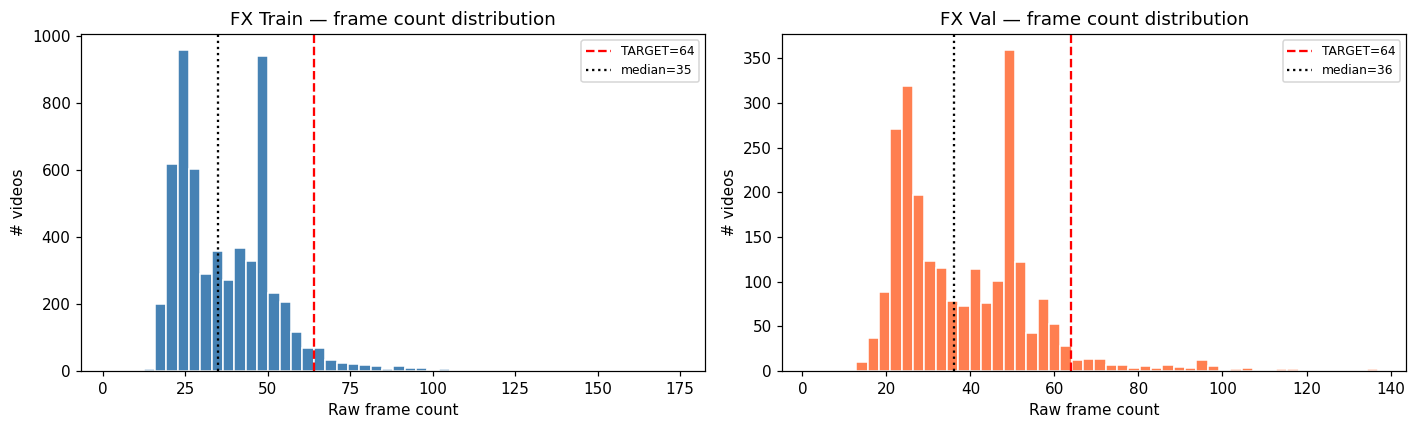

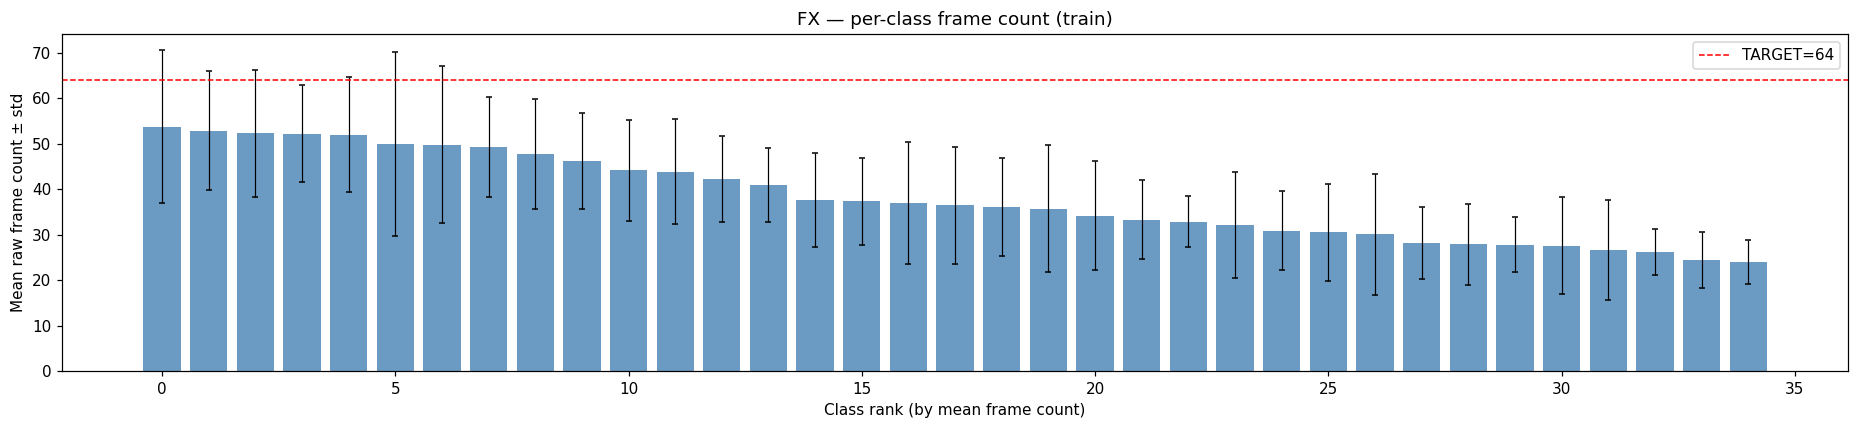

Between-class CV of mean frame count: 0.246


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, fc, color) in zip(axes, [
    ('Train', fc_train, 'steelblue'),
    ('Val',   fc_val,   'coral'),
]):
    ax.hist(fc, bins=50, color=color, edgecolor='white')
    ax.axvline(64, color='red',   linestyle='--', linewidth=1.5, label='TARGET=64')
    ax.axvline(np.median(fc), color='black', linestyle=':', linewidth=1.5,
               label=f'median={int(np.median(fc))}')
    ax.set_xlabel('Raw frame count')
    ax.set_ylabel('# videos')
    ax.set_title(f'{APPARATUS} {name} — frame count distribution')
    ax.legend(fontsize=8)
    print(f'{name}  min={fc.min()}  median={int(np.median(fc))}  '
          f'mean={fc.mean():.1f}  max={fc.max()}  '
          f'shorter_than_64: {(fc<64).sum()} ({(fc<64).mean():.1%})')

plt.tight_layout()
plt.show()

# Per-class mean frame count
class_mean_fc = np.array([fc_train[y_train == c].mean() if (y_train == c).sum() > 0 else 0
                           for c in classes])
class_std_fc  = np.array([fc_train[y_train == c].std()  if (y_train == c).sum() > 1 else 0
                           for c in classes])

fig, ax = plt.subplots(figsize=(max(10, num_classes // 2), 4))
sort_idx = np.argsort(class_mean_fc)[::-1]
x = np.arange(num_classes)
ax.bar(x, class_mean_fc[sort_idx], color='steelblue', alpha=0.8)
ax.errorbar(x, class_mean_fc[sort_idx], yerr=class_std_fc[sort_idx],
            fmt='none', color='black', capsize=2, linewidth=0.8)
ax.axhline(64, color='red', linestyle='--', linewidth=1, label='TARGET=64')
ax.set_xlabel('Class rank (by mean frame count)')
ax.set_ylabel('Mean raw frame count ± std')
ax.set_title(f'{APPARATUS} — per-class frame count (train)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Between-class CV of mean frame count: {class_mean_fc[class_mean_fc>0].std()/class_mean_fc[class_mean_fc>0].mean():.3f}')

---
## 5. Skeleton Coordinate Analysis

In [13]:
# Coordinate space check on a sample from the subset
# Check raw annotations to get pixel-space reference
sample_ann = None
if APPARATUS != 'all':
    lo_g = apparatus_label_offset
    hi_g = apparatus_label_offset + num_classes - 1
    for ann in anns99:
        if lo_g <= int(ann['label']) <= hi_g:
            sample_ann = ann
            break
else:
    sample_ann = anns99[0]

if sample_ann:
    kp = np.asarray(sample_ann['keypoint'], dtype=np.float32)
    if kp.ndim == 4:
        kp = kp[0]
    print(f'Raw keypoint shape: {kp.shape}  (T, J, 2)')
    print(f'X  min={kp[:,:,0].min():.1f}  max={kp[:,:,0].max():.1f}  mean={kp[:,:,0].mean():.1f}')
    print(f'Y  min={kp[:,:,1].min():.1f}  max={kp[:,:,1].max():.1f}  mean={kp[:,:,1].mean():.1f}')
    space = 'pixel space' if kp.max() > 2 else 'normalized [0,1]'
    print(f'Coordinate space: {space}')
    if 'img_shape' in sample_ann:
        print(f'Image shape: {sample_ann["img_shape"]}')

# Processed tensor stats
print(f'\nProcessed X_train: {X_train.shape}  min={X_train.min():.3f}  max={X_train.max():.3f}')

Raw keypoint shape: (30, 17, 2)  (T, J, 2)
X  min=880.0  max=1314.0  mean=1087.9
Y  min=280.0  max=806.5  mean=488.3
Coordinate space: pixel space
Image shape: (1080, 1920)

Processed X_train: (5824, 2, 48, 18, 1)  min=-243.875  max=1923.000


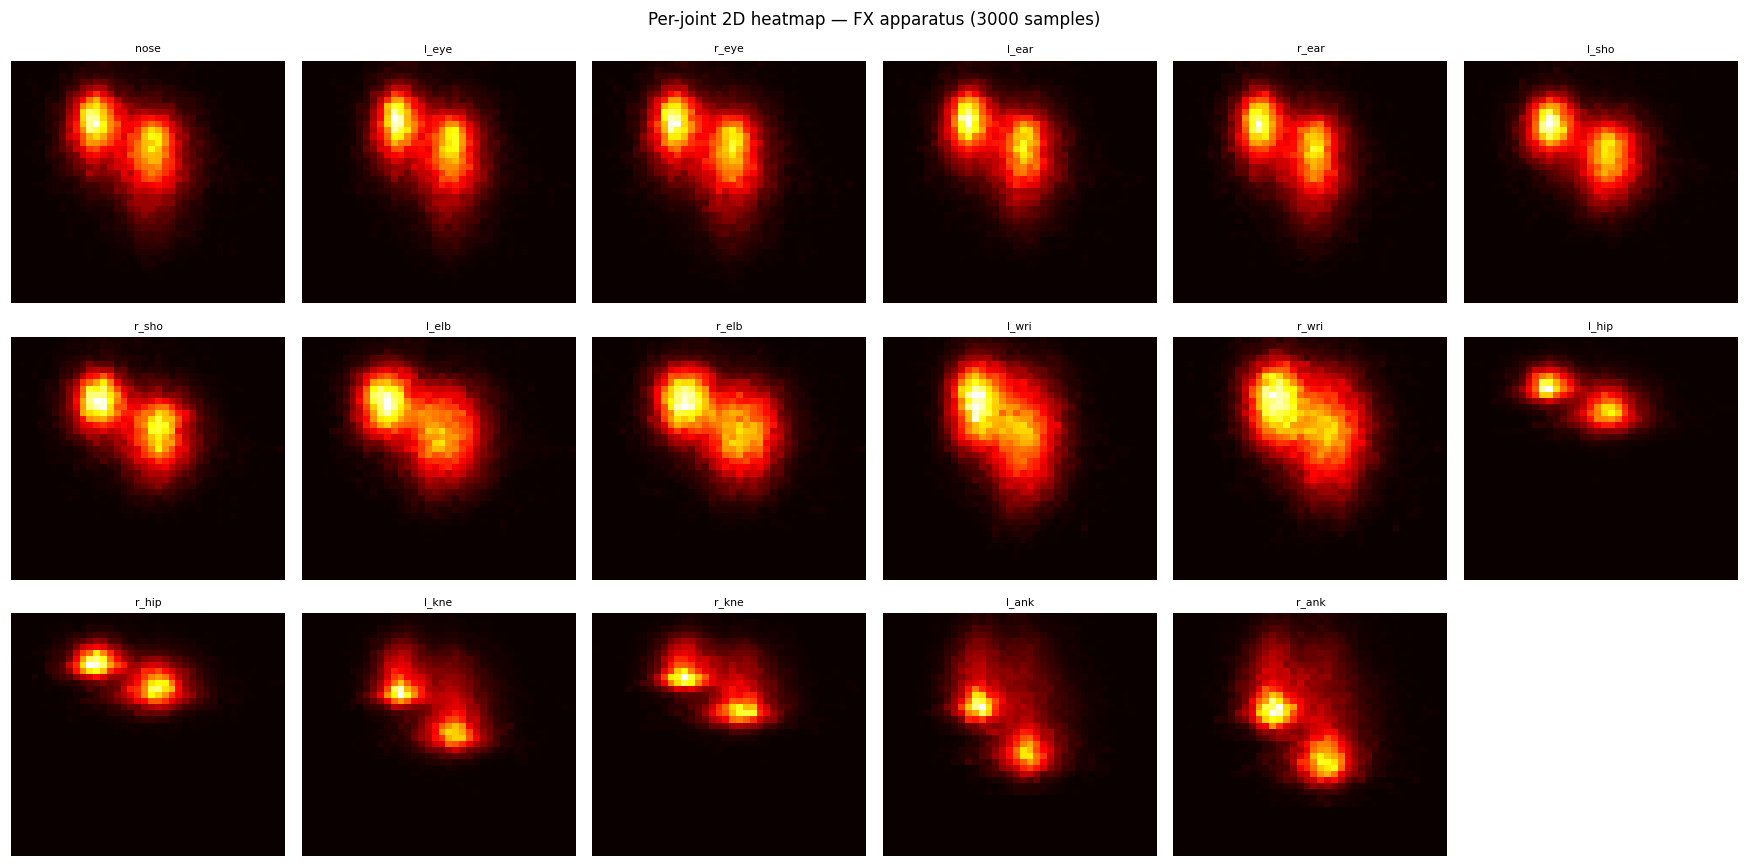

In [14]:
# Per-joint 2D position heatmaps (from raw Gym99 annotations, subset only)
rng = np.random.default_rng(SEED)

if APPARATUS != 'all':
    lo_g = apparatus_label_offset
    hi_g = apparatus_label_offset + num_classes - 1
    subset_anns = [a for a in anns99 if lo_g <= int(a['label']) <= hi_g]
else:
    subset_anns = anns99

N_SAMPLE = min(3000, len(subset_anns))
sample_idx = rng.choice(len(subset_anns), N_SAMPLE, replace=False)

all_kpts = []
for i in sample_idx:
    kp = np.asarray(subset_anns[i]['keypoint'], dtype=np.float32)
    if kp.ndim == 4:
        kp = kp[0]
    all_kpts.append(kp.reshape(-1, kp.shape[-2], 2)[:, :17, :])
all_kpts = np.concatenate(all_kpts, axis=0)  # (N*T, 17, 2)

COCO17_NAMES = ['nose','l_eye','r_eye','l_ear','r_ear',
                'l_sho','r_sho','l_elb','r_elb','l_wri','r_wri',
                'l_hip','r_hip','l_kne','r_kne','l_ank','r_ank']

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()
for j in range(17):
    x = all_kpts[:, j, 0]
    y = all_kpts[:, j, 1]
    valid = (x > 0) & (y > 0)
    ax = axes[j]
    ax.hist2d(x[valid], y[valid], bins=40, cmap='hot')
    ax.invert_yaxis()
    ax.set_title(COCO17_NAMES[j], fontsize=7)
    ax.axis('off')
for j in range(17, len(axes)):
    axes[j].axis('off')
fig.suptitle(f'Per-joint 2D heatmap — {APPARATUS} apparatus ({N_SAMPLE} samples)', fontsize=11)
plt.tight_layout()
plt.show()

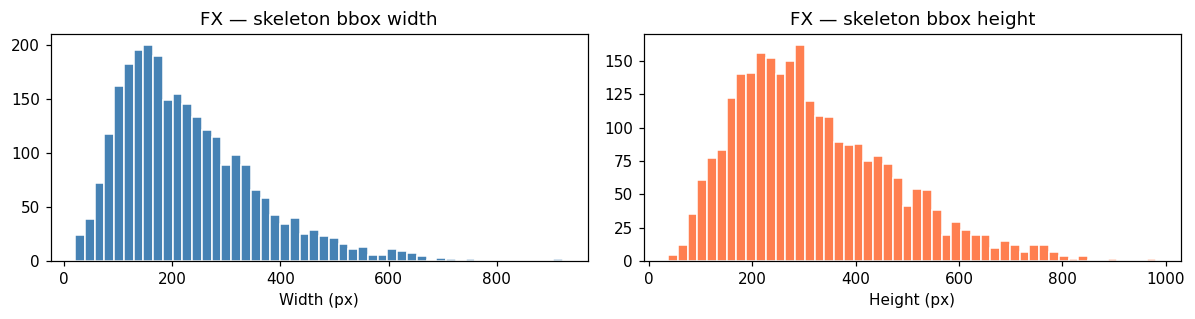

Width   mean=229.8  std=128.2
Height  mean=322.7  std=154.2


In [15]:
# Bounding box size distribution for the subset
bbox_widths, bbox_heights = [], []
for i in sample_idx:
    kp = np.asarray(subset_anns[i]['keypoint'], dtype=np.float32)
    if kp.ndim == 4:
        kp = kp[0]
    mid = kp[kp.shape[0] // 2, :17]  # (17, 2)
    valid = mid[(mid[:, 0] > 0) & (mid[:, 1] > 0)]
    if len(valid) > 1:
        bbox_widths.append(valid[:, 0].max() - valid[:, 0].min())
        bbox_heights.append(valid[:, 1].max() - valid[:, 1].min())

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(bbox_widths,  bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Width (px)');  axes[0].set_title(f'{APPARATUS} — skeleton bbox width')
axes[1].hist(bbox_heights, bins=50, color='coral',     edgecolor='white')
axes[1].set_xlabel('Height (px)'); axes[1].set_title(f'{APPARATUS} — skeleton bbox height')
plt.tight_layout(); plt.show()
print(f'Width   mean={np.mean(bbox_widths):.1f}  std={np.std(bbox_widths):.1f}')
print(f'Height  mean={np.mean(bbox_heights):.1f}  std={np.std(bbox_heights):.1f}')

---
## 6. Motion Analysis

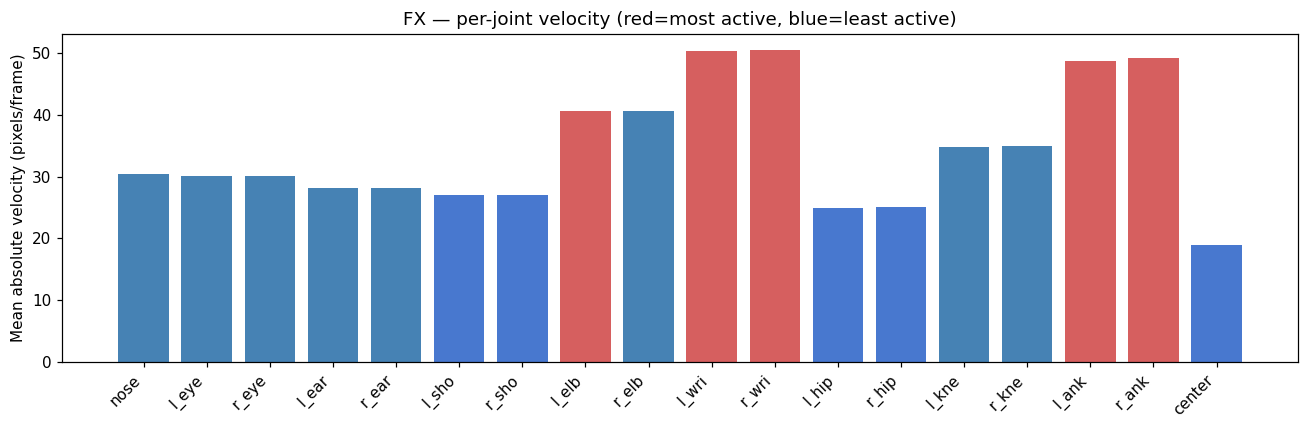

Most  active: ['r_wri', 'l_wri', 'r_ank', 'l_ank', 'l_elb']
Least active: ['l_sho', 'r_sho', 'r_hip', 'l_hip', 'center']


In [16]:
# Per-joint velocity on train subset
COCO18_NAMES = COCO17_NAMES + ['center']
N_MOTION = min(3000, X_train.shape[0])
idx_motion = rng.choice(X_train.shape[0], N_MOTION, replace=False)
sub = X_train[idx_motion]  # (N, 2, T, 18, 1)

dx = np.abs(np.diff(sub[:, 0, :, :, 0], axis=1))  # (N, T-1, 18)
dy = np.abs(np.diff(sub[:, 1, :, :, 0], axis=1))
vel = (dx + dy).mean(axis=(0, 1))  # (18,)

colors_v = ['#d65f5f' if v > np.percentile(vel, 75) else
             '#4878cf' if v < np.percentile(vel, 25) else
             'steelblue' for v in vel]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(18), vel, color=colors_v)
ax.set_xticks(range(18))
ax.set_xticklabels(COCO18_NAMES, rotation=45, ha='right')
ax.set_ylabel('Mean absolute velocity (pixels/frame)')
ax.set_title(f'{APPARATUS} — per-joint velocity (red=most active, blue=least active)')
plt.tight_layout(); plt.show()

sorted_joints = np.argsort(vel)[::-1]
print('Most  active:', [COCO18_NAMES[j] for j in sorted_joints[:5]])
print('Least active:', [COCO18_NAMES[j] for j in sorted_joints[-5:]])

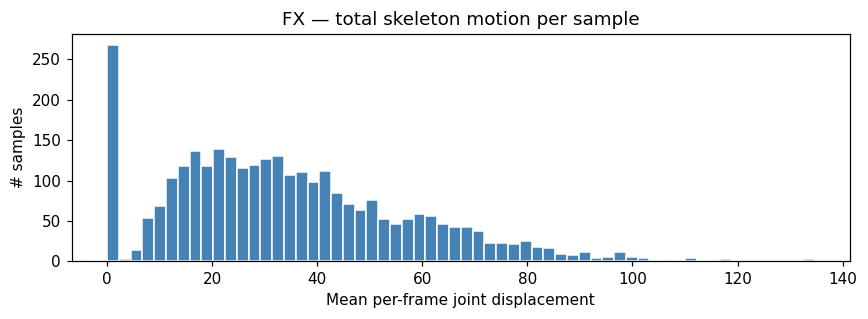

Motion  mean=34.408  std=22.983  min=0.000  max=134.654


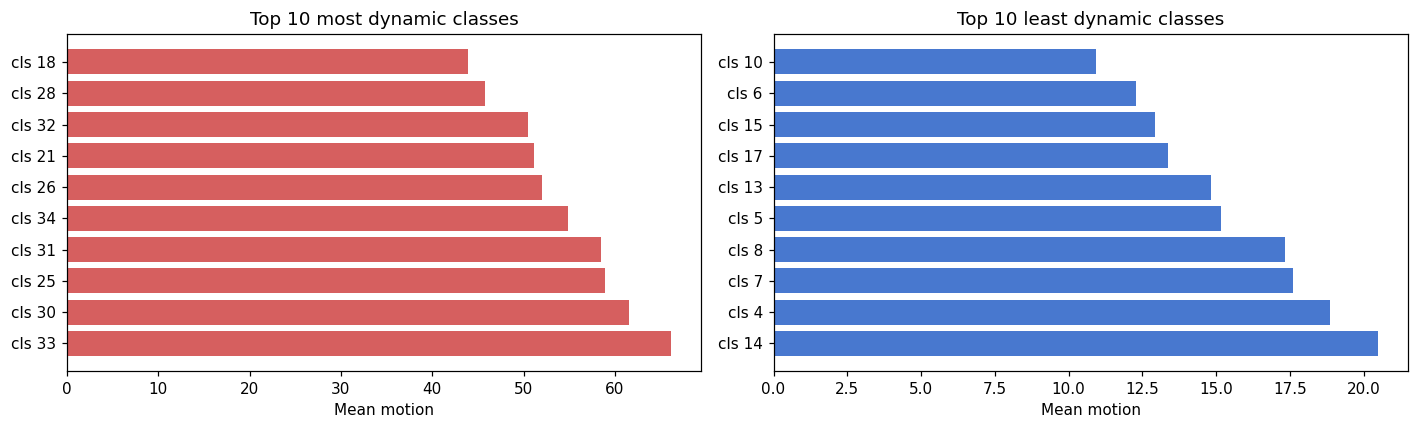

In [17]:
# Per-sample total motion + most/least dynamic classes
total_motion = (dx + dy).mean(axis=(1, 2))  # (N,)
motion_labels = y_train[idx_motion]

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(total_motion, bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean per-frame joint displacement')
ax.set_ylabel('# samples')
ax.set_title(f'{APPARATUS} — total skeleton motion per sample')
plt.tight_layout(); plt.show()
print(f'Motion  mean={total_motion.mean():.3f}  std={total_motion.std():.3f}  '
      f'min={total_motion.min():.3f}  max={total_motion.max():.3f}')

class_motion = {c: total_motion[motion_labels == c].mean()
                for c in np.unique(motion_labels) if (motion_labels == c).sum() > 1}
sorted_by_motion = sorted(class_motion.items(), key=lambda x: x[1], reverse=True)
n_show = min(10, len(sorted_by_motion))
top_n, bot_n = sorted_by_motion[:n_show], sorted_by_motion[-n_show:]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh([f'cls {c}' for c, _ in top_n], [v for _, v in top_n], color='#d65f5f')
axes[0].set_xlabel('Mean motion'); axes[0].set_title(f'Top {n_show} most dynamic classes')
axes[1].barh([f'cls {c}' for c, _ in bot_n], [v for _, v in bot_n], color='#4878cf')
axes[1].set_xlabel('Mean motion'); axes[1].set_title(f'Top {n_show} least dynamic classes')
plt.tight_layout(); plt.show()

---
## 7. Class Separability — PCA & t-SNE

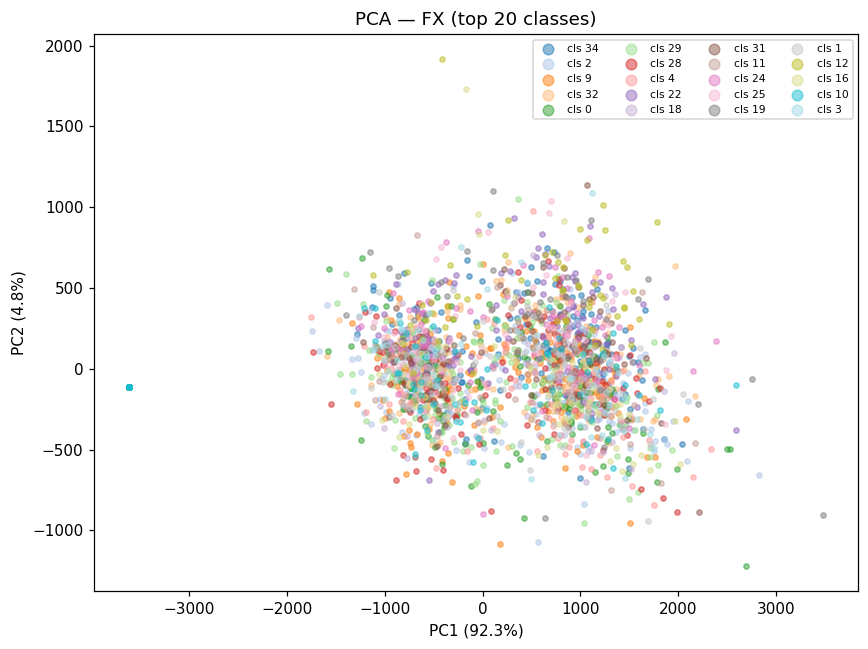

PC1=92.3%  PC2=4.8%  cumulative=97.1%


In [18]:
# Features: mean skeleton position over time → (N, 36)
N_TSNE = min(3000, X_train.shape[0])
idx_tsne = rng.choice(X_train.shape[0], N_TSNE, replace=False)
sub_tsne = X_train[idx_tsne]  # (N, 2, T, 18, 1)
feats = sub_tsne[:, :, :, :, 0].mean(axis=2).reshape(N_TSNE, -1)  # (N, 36)
lbls_tsne = y_train[idx_tsne]

n_top = min(20, num_classes)
top_classes = [c for c, _ in Counter(lbls_tsne.tolist()).most_common(n_top)]
mask_top = np.isin(lbls_tsne, top_classes)
feats_top = feats[mask_top]
lbls_top  = lbls_tsne[mask_top]

pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(feats_top)

cmap = plt.get_cmap('tab20')
fig, ax = plt.subplots(figsize=(8, 6))
for i, c in enumerate(top_classes):
    m = lbls_top == c
    ax.scatter(pca_coords[m, 0], pca_coords[m, 1],
               s=12, alpha=0.5, color=cmap(i / n_top), label=f'cls {c}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'PCA — {APPARATUS} (top {n_top} classes)')
ax.legend(ncol=4, fontsize=7, markerscale=2)
plt.tight_layout(); plt.show()
print(f'PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}  '
      f'cumulative={pca.explained_variance_ratio_.sum():.1%}')

Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


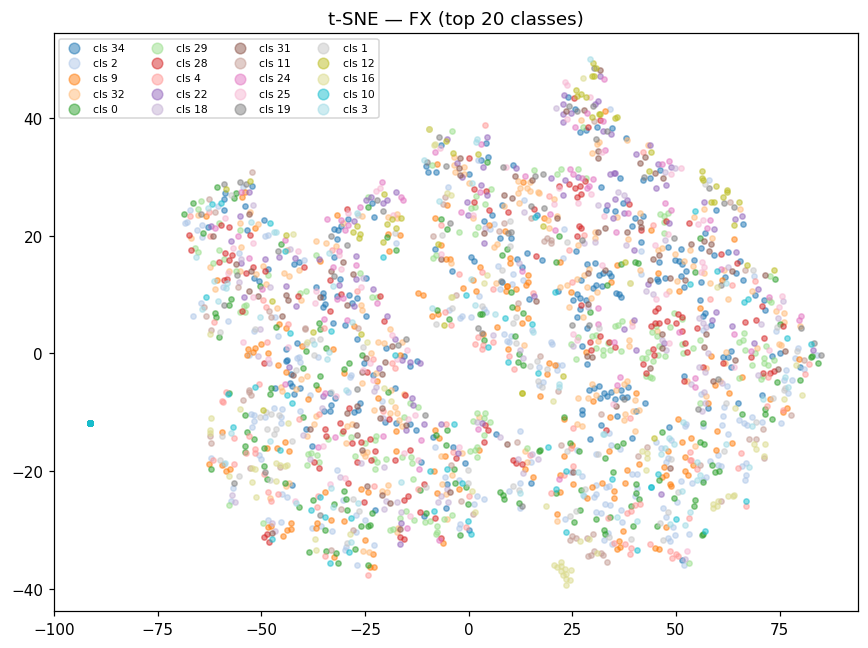

In [19]:
print('Running t-SNE...')
tsne = TSNE(n_components=2, perplexity=min(30, len(feats_top) // 4), random_state=SEED, n_iter=1000)
tsne_coords = tsne.fit_transform(feats_top)

fig, ax = plt.subplots(figsize=(8, 6))
for i, c in enumerate(top_classes):
    m = lbls_top == c
    ax.scatter(tsne_coords[m, 0], tsne_coords[m, 1],
               s=12, alpha=0.5, color=cmap(i / n_top), label=f'cls {c}')
ax.set_title(f't-SNE — {APPARATUS} (top {n_top} classes)')
ax.legend(ncol=4, fontsize=7, markerscale=2)
plt.tight_layout(); plt.show()

---
## 8. Sample Visualization

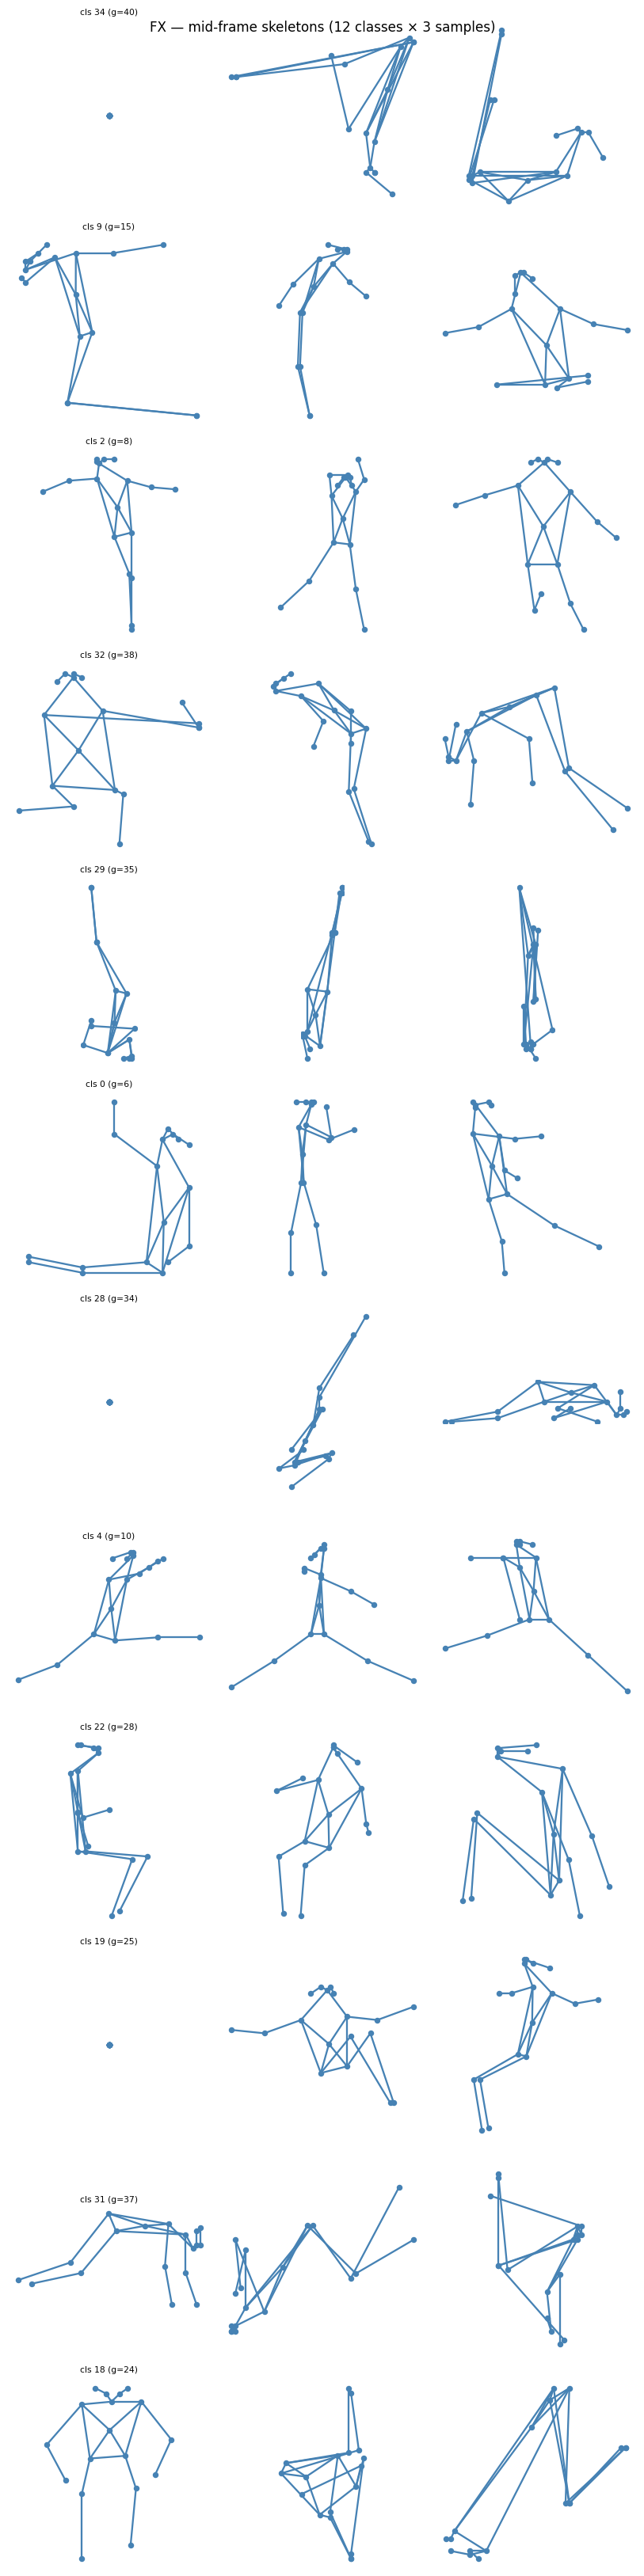

In [20]:
from src.joint_specs import get_joint_spec

spec = get_joint_spec('coco18')

def draw_skeleton(ax, tensor_sample, t, bone_pairs, color='steelblue', title=''):
    """Draw one frame from a (2, T, 18, 1) tensor."""
    xy = np.stack([tensor_sample[0, t, :, 0],
                   tensor_sample[1, t, :, 0]], axis=1)  # (18, 2)
    for p, c in bone_pairs:
        ax.plot([xy[p, 0], xy[c, 0]], [xy[p, 1], xy[c, 1]], color=color, lw=1.5)
    ax.scatter(xy[:, 0], xy[:, 1], s=15, color=color, zorder=5)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    ax.set_title(title, fontsize=7)

# Grid: one random sample per class (up to N_SHOW_CLASSES classes)
N_SHOW_CLASSES = min(num_classes, 12)
show_classes = [c for c, _ in Counter(y_train.tolist()).most_common(N_SHOW_CLASSES)]
N_PER_CLASS = 3
mid_t = X_train.shape[2] // 2

fig, axes = plt.subplots(N_SHOW_CLASSES, N_PER_CLASS,
                         figsize=(N_PER_CLASS * 2.5, N_SHOW_CLASSES * 2.5))
if N_SHOW_CLASSES == 1:
    axes = axes[np.newaxis, :]

for row, cls in enumerate(show_classes):
    cls_idx = np.where(y_train == cls)[0]
    picks = rng.choice(cls_idx, min(N_PER_CLASS, len(cls_idx)), replace=False)
    for col in range(N_PER_CLASS):
        ax = axes[row, col]
        if col < len(picks):
            global_lbl = cls + apparatus_label_offset
            title = f'cls {cls} (g={global_lbl})' if col == 0 else ''
            draw_skeleton(ax, X_train[picks[col]], mid_t, spec.bone_pairs,
                          color='steelblue', title=title)
        else:
            ax.axis('off')

fig.suptitle(f'{APPARATUS} — mid-frame skeletons ({N_SHOW_CLASSES} classes × {N_PER_CLASS} samples)',
             fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Frame-by-frame display: 4 random samples, each shown as a row of evenly-spaced frames
N_SAMPLES = 4
N_FRAMES  = 8                              # frames to show per sample
T = X_train.shape[2]                       # 64
frame_ticks = np.linspace(0, T - 1, N_FRAMES, dtype=int)

sample_idx = rng.choice(len(X_train), N_SAMPLES, replace=False)

fig, axes = plt.subplots(N_SAMPLES, N_FRAMES, figsize=(N_FRAMES * 2.2, N_SAMPLES * 3.0))
cmap_t = plt.cm.plasma(np.linspace(0.15, 0.85, N_FRAMES))

for row, si in enumerate(sample_idx):
    cls        = int(y_train[si])
    global_lbl = cls + apparatus_label_offset
    for col, t in enumerate(frame_ticks):
        ax = axes[row, col]
        draw_skeleton(ax, X_train[si], t, spec.bone_pairs,
                      color=cmap_t[col],
                      title=f'f={t}' if row == 0 else '')
        if col == 0:
            ax.set_title(f'f={t}', fontsize=8)
            ax.text(-0.15, 0.5, f'cls {cls}\n(g={global_lbl})',
                    transform=ax.transAxes, fontsize=8,
                    va='center', ha='right', rotation=0)

fig.suptitle(f'{APPARATUS} — frame samples  ({N_SAMPLES} random training samples × {N_FRAMES} frames)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()